# Lab: Image Segmentation – Region Splitting and Merging

## Introduction

Image segmentation is the process of partitioning an image into multiple segments (sets of pixels) to simplify and/or change the representation of an image into something more meaningful and easier to analyze.

### Region Splitting and Merging

**Region Splitting and Merging** is a hybrid segmentation technique that combines:
- **Splitting**: Divides an image into regions based on homogeneity criteria
- **Merging**: Combines adjacent regions that satisfy similarity criteria

### Algorithm Overview

1. **Initialization**: Start with the entire image as one region
2. **Splitting Phase**: 
   - If a region doesn't satisfy homogeneity criteria, split it into quadrants
   - Recursively apply splitting to each quadrant
3. **Merging Phase**:
   - Merge adjacent regions that satisfy similarity criteria
   - Continue until no more merges are possible

### Advantages
- Handles complex images with multiple objects
- Can adapt to local image characteristics
- More flexible than simple thresholding

### Disadvantages
- Computationally expensive
- Requires careful selection of homogeneity/similarity criteria
- May over-segment or under-segment depending on parameters


In [3]:

import numpy as np
import cv2
from skimage import segmentation
from skimage.filters import threshold_multiotsu
from skimage.segmentation import slic, mark_boundaries
from skimage.color import label2rgb
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualization
plt.style.use('default')
plt.rcParams['figure.figsize'] = (15, 10)


## Step 1: Load and Prepare Test Image

We'll use a complex image with multiple objects. If you have a custom image, you can load it, otherwise we'll create a synthetic test image.


Using synthetic test image


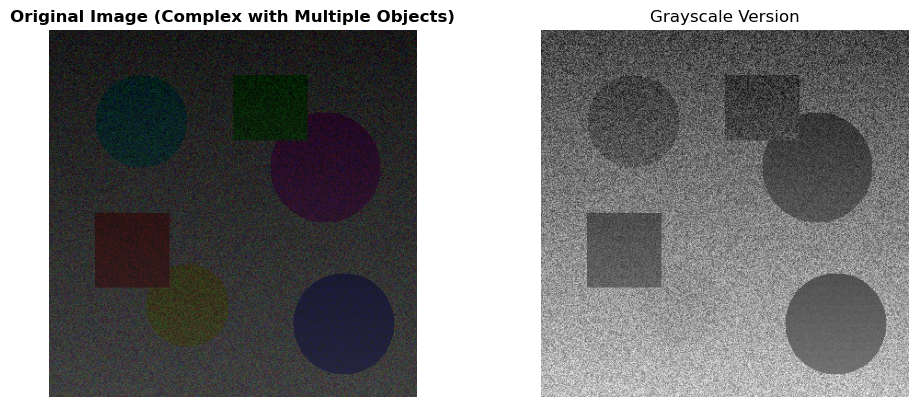

Image shape: (400, 400, 3)
Image dtype: uint8


In [4]:
# Create a synthetic complex image with multiple objects
def create_test_image():
    """Create a synthetic image with multiple objects for testing"""
    img = np.zeros((400, 400, 3), dtype=np.uint8)
    
    # Add multiple circular objects
    cv2.circle(img, (100, 100), 50, (255, 0, 0), -1)  # Blue circle
    cv2.circle(img, (300, 150), 60, (0, 255, 0), -1)  # Green circle
    cv2.circle(img, (150, 300), 45, (0, 0, 255), -1)  # Red circle
    cv2.circle(img, (320, 320), 55, (255, 255, 0), -1)  # Cyan circle
    
    # Add rectangular objects
    cv2.rectangle(img, (200, 50), (280, 120), (255, 0, 255), -1)  # Magenta rectangle
    cv2.rectangle(img, (50, 200), (130, 280), (0, 255, 255), -1)  # Yellow rectangle
    
    # Add some noise
    noise = np.random.randint(0, 50, (400, 400, 3), dtype=np.uint8)
    img = cv2.add(img, noise)
    
    # Add gradient background
    for i in range(400):
        img[i, :, :] = np.clip(img[i, :, :] + i//10, 0, 255)
    
    return img

# Load or create test image
try:
    # Try to load a custom image (uncomment and provide path)
    # image = cv2.imread('path_to_your_image.jpg')
    # image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # For this demo, create synthetic image
    image = create_test_image()
    image_rgb = image.copy()
    print("Using synthetic test image")
except:
    print("Error loading image, using synthetic image")
    image = create_test_image()
    image_rgb = image.copy()

# Convert to grayscale for some operations
image_gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY) if len(image.shape) == 3 else image

# Display original image
plt.figure(figsize=(10, 8))
plt.subplot(2, 2, 1)
plt.imshow(image_rgb)
plt.title('Original Image (Complex with Multiple Objects)', fontsize=12, fontweight='bold')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(image_gray, cmap='gray')
plt.title('Grayscale Version', fontsize=12)
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Image shape: {image_rgb.shape}")
print(f"Image dtype: {image_rgb.dtype}")


## Step 2: Region Splitting and Merging Implementation

We'll implement a quad-tree based region splitting and merging algorithm.


In [8]:
class RegionSplitMerge:
    """Region Splitting and Merging Algorithm"""
    
    def __init__(self, image, threshold=30, min_region_size=4):
        """
        Initialize the algorithm
        
        Parameters:
        -----------
        image : ndarray
            Input image (grayscale)
        threshold : float
            Homogeneity threshold (standard deviation)
        min_region_size : int
            Minimum region size to avoid over-segmentation
        """
        self.image = image.astype(np.float32)
        self.threshold = threshold
        self.min_region_size = min_region_size
        self.height, self.width = image.shape
        self.regions = np.zeros((self.height, self.width), dtype=np.int32)
        self.region_id = 1
        
    def is_homogeneous(self, x1, y1, x2, y2):
        """
        Check if a region is homogeneous based on standard deviation
        """
        region = self.image[y1:y2, x1:x2]
        std_dev = np.std(region)
        return std_dev <= self.threshold
    
    def split(self, x1, y1, x2, y2):
        """
        Recursively split a region if it's not homogeneous
        """
        # Check minimum size
        if (x2 - x1) <= self.min_region_size or (y2 - y1) <= self.min_region_size:
            # Assign region ID
            self.regions[y1:y2, x1:x2] = self.region_id
            self.region_id += 1
            return
        
        # Check if homogeneous
        if self.is_homogeneous(x1, y1, x2, y2):
            # Assign region ID
            self.regions[y1:y2, x1:x2] = self.region_id
            self.region_id += 1
            return
        
        # Split into quadrants
        mid_x = (x1 + x2) // 2
        mid_y = (y1 + y2) // 2
        
        # Recursively split each quadrant
        self.split(x1, y1, mid_x, mid_y)  # Top-left
        self.split(mid_x, y1, x2, mid_y)  # Top-right
        self.split(x1, mid_y, mid_x, y2)  # Bottom-left
        self.split(mid_x, mid_y, x2, y2)  # Bottom-right
    
    def get_region_mean(self, region_id):
        """Get mean intensity of a region"""
        mask = self.regions == region_id
        return np.mean(self.image[mask])
    
    def should_merge(self, region1_id, region2_id):
        """Check if two regions should be merged"""
        mean1 = self.get_region_mean(region1_id)
        mean2 = self.get_region_mean(region2_id)
        return abs(mean1 - mean2) <= self.threshold
    
    def merge(self):
        """
        Merge adjacent regions that are similar
        """
        changed = True
        iterations = 0
        max_iterations = 10
        
        while changed and iterations < max_iterations:
            changed = False
            iterations += 1
            
            # Get unique region IDs
            unique_regions = np.unique(self.regions)
            
            # Create a mapping for merging
            merge_map = {r: r for r in unique_regions}
            
            # Check adjacent regions
            for i in range(1, self.height - 1):
                for j in range(1, self.width - 1):
                    current_id = self.regions[i, j]
                    
                    # Check neighbors (4-connected)
                    neighbors = [
                        self.regions[i-1, j],  # Top
                        self.regions[i+1, j],  # Bottom
                        self.regions[i, j-1],  # Left
                        self.regions[i, j+1]   # Right
                    ]
                    
                    for neighbor_id in neighbors:
                        if neighbor_id != current_id and neighbor_id != 0:
                            if self.should_merge(current_id, neighbor_id):
                                # Merge: assign smaller ID to both
                                min_id = min(current_id, neighbor_id)
                                max_id = max(current_id, neighbor_id)
                                merge_map[max_id] = min_id
                                changed = True
            
            # Apply merge mapping
            new_regions = self.regions.copy()
            for old_id, new_id in merge_map.items():
                new_regions[self.regions == old_id] = new_id
            
            self.regions = new_regions
        
        return self.regions
    
    def segment(self):
        """Perform complete segmentation"""
        # Phase 1: Splitting
        print("Phase 1: Splitting regions...")
        self.split(0, 0, self.width, self.height)
        
        # Phase 2: Merging
        print("Phase 2: Merging similar regions...")
        self.merge()
        
        return self.regions


Applying Region Splitting and Merging Algorithm...
Phase 1: Splitting regions...
Phase 2: Merging similar regions...


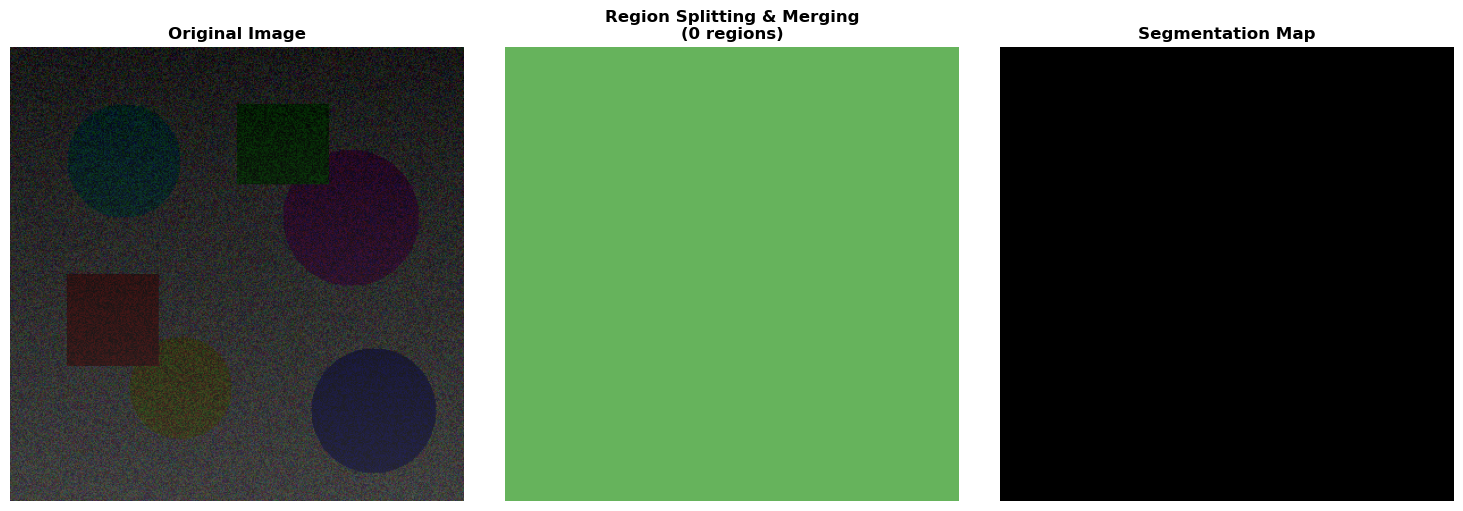


Number of segmented regions: 0
Segmentation complete!


In [9]:
# Apply Region Splitting and Merging
print("Applying Region Splitting and Merging Algorithm...")
print("=" * 60)

# Create segmenter
segmenter = RegionSplitMerge(image_gray, threshold=25, min_region_size=8)

# Perform segmentation
segmented_regions = segmenter.segment()

# Create colored segmentation result
def colorize_segmentation(regions):
    """Colorize segmentation regions for visualization"""
    unique_regions = np.unique(regions)
    colored = np.zeros((regions.shape[0], regions.shape[1], 3), dtype=np.uint8)
    
    # Assign random colors to each region
    np.random.seed(42)  # For reproducible colors
    colors = {}
    for region_id in unique_regions:
        if region_id > 0:
            colors[region_id] = np.random.randint(0, 255, 3)
    
    for region_id, color in colors.items():
        colored[regions == region_id] = color
    
    return colored

segmented_colored = colorize_segmentation(segmented_regions)

# Display results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title('Original Image', fontsize=12, fontweight='bold')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(segmented_colored)
plt.title(f'Region Splitting & Merging\n({len(np.unique(segmented_regions))-1} regions)', 
          fontsize=12, fontweight='bold')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(segmented_regions, cmap='nipy_spectral')
plt.title('Segmentation Map', fontsize=12, fontweight='bold')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"\nNumber of segmented regions: {len(np.unique(segmented_regions)) - 1}")
print(f"Segmentation complete!")


## Step 3: Using scikit-image for Region Splitting and Merging

scikit-image provides built-in functions for region-based segmentation. We'll use the `quickshift` and `slic` algorithms which are similar in concept.


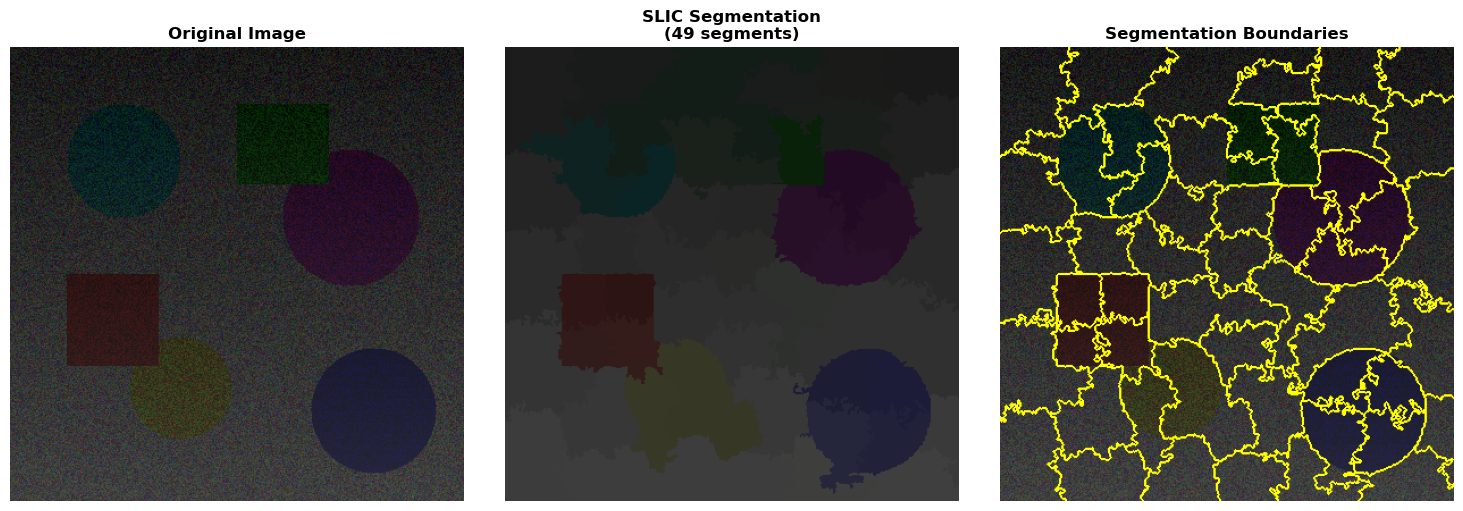

Number of SLIC segments: 49


In [10]:
# Using scikit-image SLIC (Simple Linear Iterative Clustering)
# This is similar to region splitting and merging

# Apply SLIC segmentation
segments_slic = slic(image_rgb, n_segments=100, compactness=10, sigma=1, start_label=1)

# Create colored segmentation
segmented_slic_colored = label2rgb(segments_slic, image_rgb, kind='avg')

# Mark boundaries
boundaries = mark_boundaries(image_rgb, segments_slic)

# Display results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title('Original Image', fontsize=12, fontweight='bold')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(segmented_slic_colored)
plt.title(f'SLIC Segmentation\n({len(np.unique(segments_slic))} segments)', 
          fontsize=12, fontweight='bold')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(boundaries)
plt.title('Segmentation Boundaries', fontsize=12, fontweight='bold')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Number of SLIC segments: {len(np.unique(segments_slic))}")


## Step 4: Thresholding Methods for Comparison

Let's compare with simple thresholding techniques to see the differences.


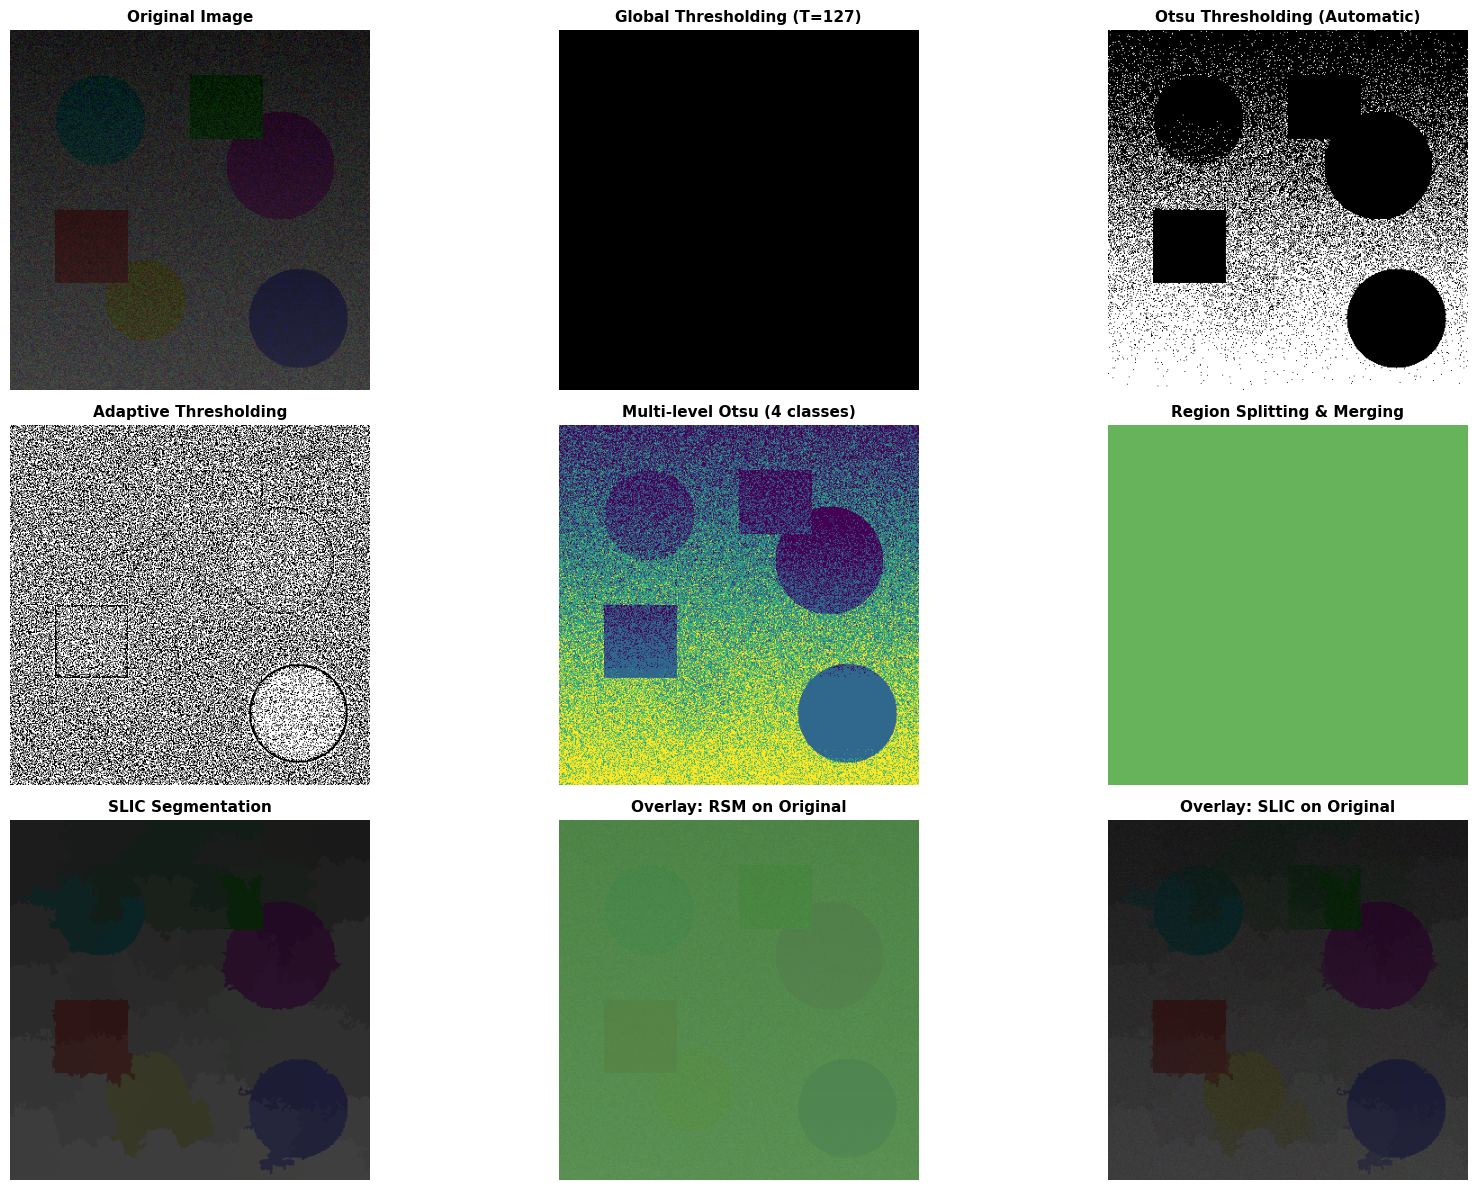

Thresholding Results Summary:
  - Global Threshold: Binary image with threshold = 127
  - Otsu Threshold: Automatic optimal threshold
  - Adaptive Threshold: Local thresholding
  - Multi-level Otsu: 4 classes


In [11]:
# Method 1: Simple Global Thresholding
_, binary_global = cv2.threshold(image_gray, 127, 255, cv2.THRESH_BINARY)

# Method 2: Otsu's Automatic Thresholding
_, binary_otsu = cv2.threshold(image_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Method 3: Adaptive Thresholding
binary_adaptive = cv2.adaptiveThreshold(
    image_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
    cv2.THRESH_BINARY, 11, 2
)

# Method 4: Multi-level Otsu (for multiple objects)
thresholds = threshold_multiotsu(image_gray, classes=4)
regions_multiotsu = np.digitize(image_gray, bins=thresholds)

# Display thresholding results
plt.figure(figsize=(18, 12))

plt.subplot(3, 3, 1)
plt.imshow(image_rgb)
plt.title('Original Image', fontsize=11, fontweight='bold')
plt.axis('off')

plt.subplot(3, 3, 2)
plt.imshow(binary_global, cmap='gray')
plt.title('Global Thresholding (T=127)', fontsize=11, fontweight='bold')
plt.axis('off')

plt.subplot(3, 3, 3)
plt.imshow(binary_otsu, cmap='gray')
plt.title('Otsu Thresholding (Automatic)', fontsize=11, fontweight='bold')
plt.axis('off')

plt.subplot(3, 3, 4)
plt.imshow(binary_adaptive, cmap='gray')
plt.title('Adaptive Thresholding', fontsize=11, fontweight='bold')
plt.axis('off')

plt.subplot(3, 3, 5)
plt.imshow(regions_multiotsu, cmap='viridis')
plt.title('Multi-level Otsu (4 classes)', fontsize=11, fontweight='bold')
plt.axis('off')

plt.subplot(3, 3, 6)
plt.imshow(segmented_colored)
plt.title('Region Splitting & Merging', fontsize=11, fontweight='bold')
plt.axis('off')

plt.subplot(3, 3, 7)
plt.imshow(segmented_slic_colored)
plt.title('SLIC Segmentation', fontsize=11, fontweight='bold')
plt.axis('off')

# Overlay comparison
plt.subplot(3, 3, 8)
overlay = image_rgb.copy()
overlay[segmented_regions > 0] = segmented_colored[segmented_regions > 0] * 0.7 + image_rgb[segmented_regions > 0] * 0.3
plt.imshow(overlay.astype(np.uint8))
plt.title('Overlay: RSM on Original', fontsize=11, fontweight='bold')
plt.axis('off')

plt.subplot(3, 3, 9)
overlay2 = image_rgb.copy()
overlay2[segments_slic > 0] = segmented_slic_colored[segments_slic > 0] * 0.7 + image_rgb[segments_slic > 0] * 0.3
plt.imshow(overlay2.astype(np.uint8))
plt.title('Overlay: SLIC on Original', fontsize=11, fontweight='bold')
plt.axis('off')

plt.tight_layout()
plt.show()

print("Thresholding Results Summary:")
print(f"  - Global Threshold: Binary image with threshold = 127")
print(f"  - Otsu Threshold: Automatic optimal threshold")
print(f"  - Adaptive Threshold: Local thresholding")
print(f"  - Multi-level Otsu: {len(np.unique(regions_multiotsu))} classes")


## Step 5: Quantitative Comparison

Let's analyze the segmentation quality and characteristics.


SEGMENTATION METHODS COMPARISON
              method  num_regions  avg_region_size  min_region_size  max_region_size  std_region_size
Region Split & Merge            1    160000.000000           160000           160000         0.000000
                SLIC           49      3265.306122             1524            10157      1426.764632
    Multi-level Otsu            3     42298.000000            30436            55486     10269.512549


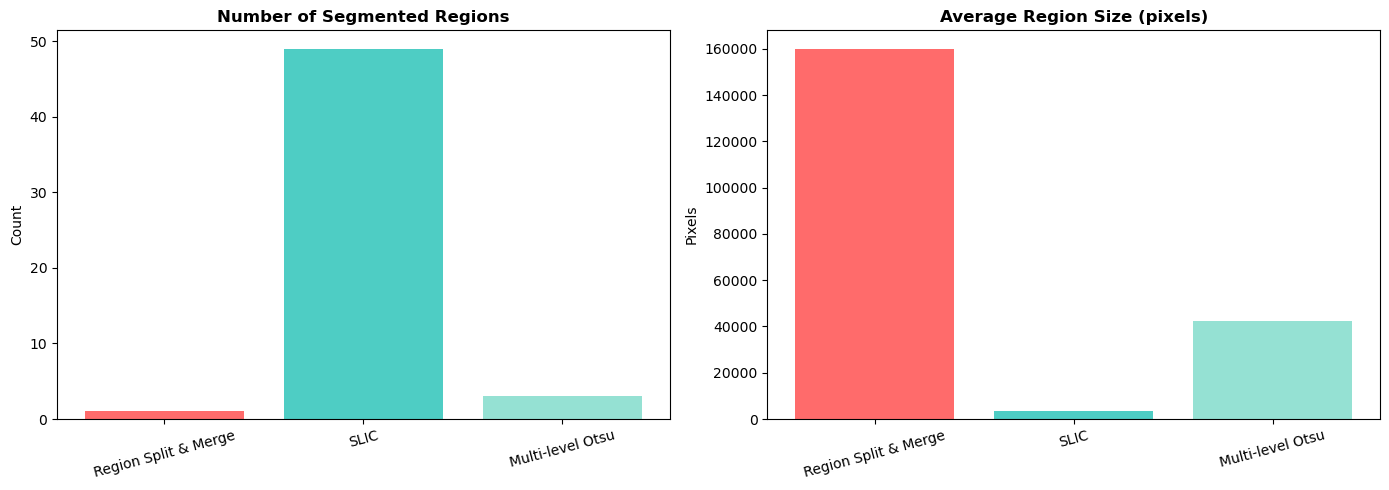

In [12]:
# Calculate statistics for each method
def calculate_segmentation_stats(segmentation, method_name):
    """Calculate statistics for segmentation"""
    unique_regions = np.unique(segmentation)
    num_regions = len(unique_regions) - (1 if 0 in unique_regions else 0)
    
    region_sizes = []
    for region_id in unique_regions:
        if region_id > 0:
            size = np.sum(segmentation == region_id)
            region_sizes.append(size)
    
    return {
        'method': method_name,
        'num_regions': num_regions,
        'avg_region_size': np.mean(region_sizes) if region_sizes else 0,
        'min_region_size': np.min(region_sizes) if region_sizes else 0,
        'max_region_size': np.max(region_sizes) if region_sizes else 0,
        'std_region_size': np.std(region_sizes) if region_sizes else 0
    }

# Calculate statistics
stats_rsm = calculate_segmentation_stats(segmented_regions, 'Region Split & Merge')
stats_slic = calculate_segmentation_stats(segments_slic, 'SLIC')
stats_multiotsu = calculate_segmentation_stats(regions_multiotsu, 'Multi-level Otsu')

# Create comparison table
comparison_data = [stats_rsm, stats_slic, stats_multiotsu]
df_comparison = pd.DataFrame(comparison_data)

print("=" * 70)
print("SEGMENTATION METHODS COMPARISON")
print("=" * 70)
print(df_comparison.to_string(index=False))
print("=" * 70)

# Visualize statistics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Number of regions
axes[0].bar(df_comparison['method'], df_comparison['num_regions'], 
            color=['#FF6B6B', '#4ECDC4', '#95E1D3'])
axes[0].set_title('Number of Segmented Regions', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

# Average region size
axes[1].bar(df_comparison['method'], df_comparison['avg_region_size'], 
            color=['#FF6B6B', '#4ECDC4', '#95E1D3'])
axes[1].set_title('Average Region Size (pixels)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Pixels')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


## Step 6: Advantages and Disadvantages Analysis

### Region Splitting and Merging

#### Advantages:
1. **Adaptive to Local Characteristics**: Can handle images with varying intensity levels
2. **Handles Complex Scenes**: Better for images with multiple objects and varying backgrounds
3. **Flexible**: Can be tuned with different homogeneity criteria
4. **Preserves Object Boundaries**: Generally maintains better object boundaries than simple thresholding
5. **No Prior Knowledge Required**: Doesn't need to know the number of objects beforehand

#### Disadvantages:
1. **Computational Cost**: More expensive than simple thresholding (O(n log n) or worse)
2. **Parameter Sensitivity**: Requires careful tuning of threshold and minimum region size
3. **Over/Under Segmentation**: May create too many or too few regions depending on parameters
4. **Memory Intensive**: Requires storing region information during processing
5. **Implementation Complexity**: More complex to implement than thresholding methods

### Thresholding Methods

#### Advantages:
1. **Fast and Simple**: Very fast computation (O(n))
2. **Easy to Implement**: Simple algorithms
3. **Memory Efficient**: Low memory requirements
4. **Good for High Contrast**: Works well when objects have distinct intensity values
5. **Deterministic**: Predictable results

#### Disadvantages:
1. **Sensitive to Illumination**: Fails with uneven lighting
2. **Poor for Complex Scenes**: Struggles with multiple objects and varying backgrounds
3. **Fixed Threshold Issues**: Global thresholding doesn't adapt to local variations
4. **Noise Sensitivity**: Affected by image noise
5. **Limited to Intensity**: Only uses intensity information, ignores spatial relationships


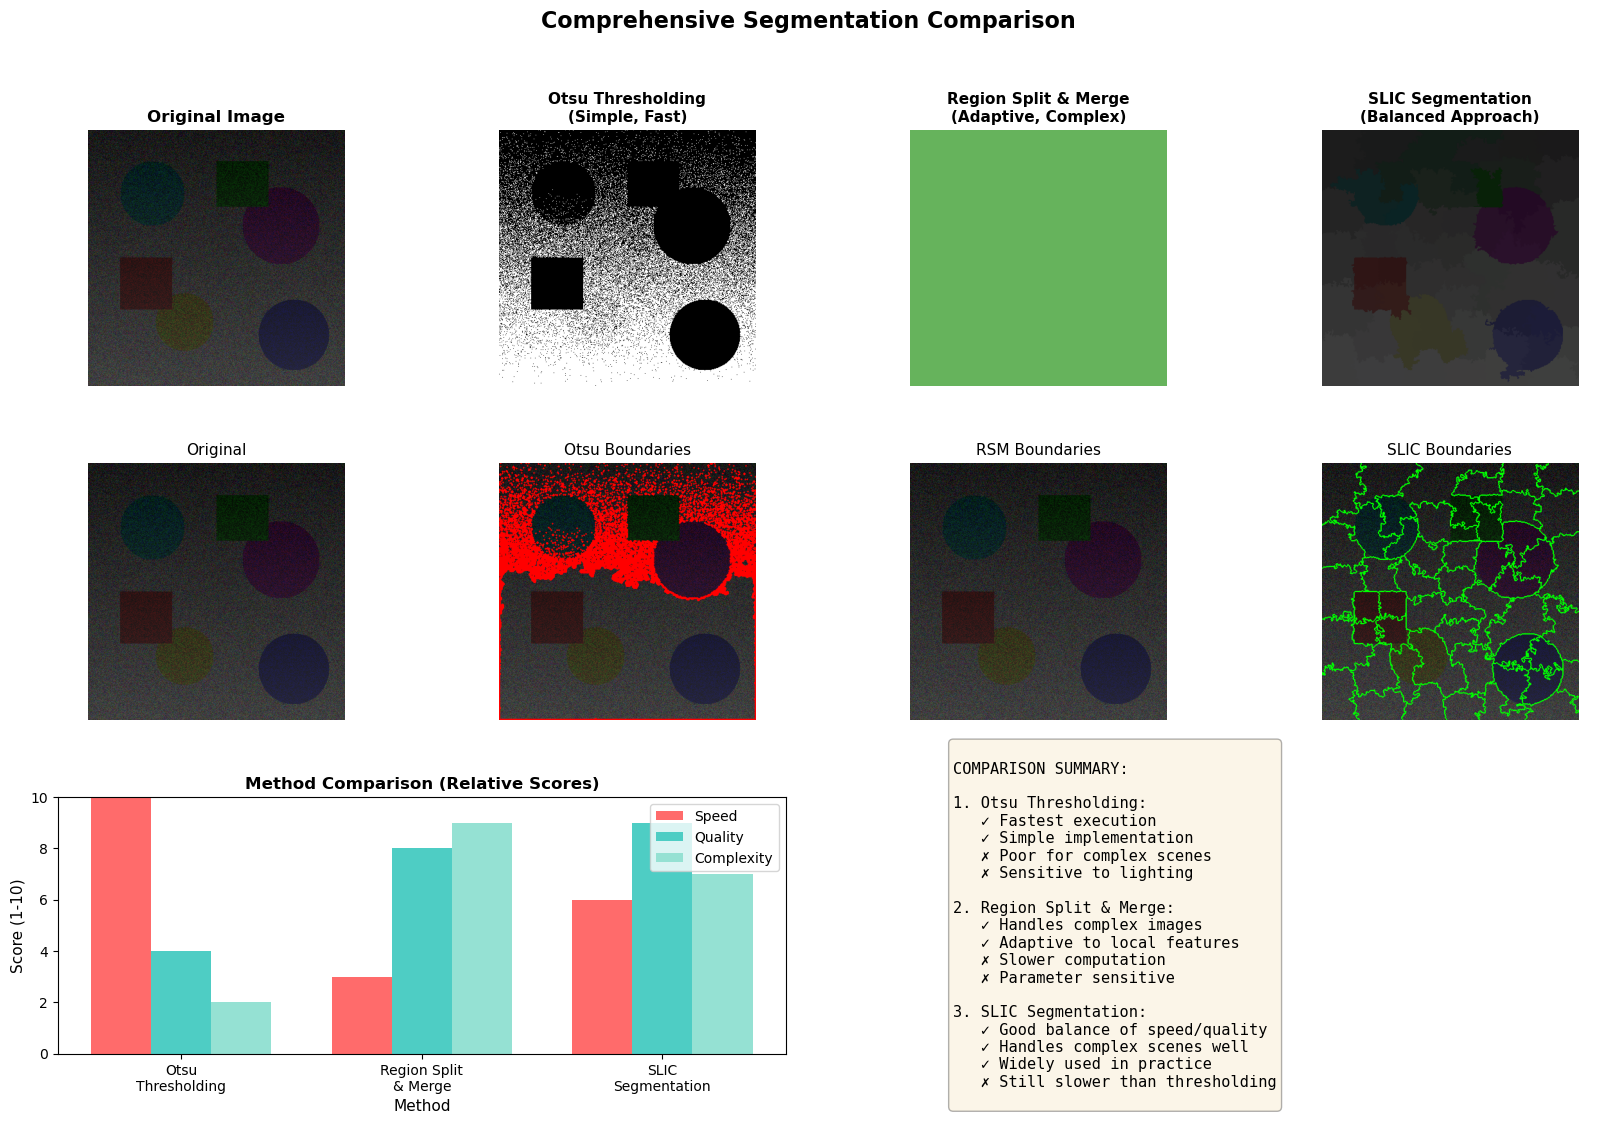

In [13]:
# Create a comprehensive comparison visualization
fig = plt.figure(figsize=(20, 12))

# Create grid
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# Row 1: Original and different methods
ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(image_rgb)
ax1.set_title('Original Image', fontsize=12, fontweight='bold')
ax1.axis('off')

ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(binary_otsu, cmap='gray')
ax2.set_title('Otsu Thresholding\n(Simple, Fast)', fontsize=11, fontweight='bold')
ax2.axis('off')

ax3 = fig.add_subplot(gs[0, 2])
ax3.imshow(segmented_colored)
ax3.set_title('Region Split & Merge\n(Adaptive, Complex)', fontsize=11, fontweight='bold')
ax3.axis('off')

ax4 = fig.add_subplot(gs[0, 3])
ax4.imshow(segmented_slic_colored)
ax4.set_title('SLIC Segmentation\n(Balanced Approach)', fontsize=11, fontweight='bold')
ax4.axis('off')

# Row 2: Boundary overlays
ax5 = fig.add_subplot(gs[1, 0])
ax5.imshow(image_rgb)
ax5.set_title('Original', fontsize=11)
ax5.axis('off')

ax6 = fig.add_subplot(gs[1, 1])
contours_otsu, _ = cv2.findContours(binary_otsu, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
img_contours_otsu = image_rgb.copy()
cv2.drawContours(img_contours_otsu, contours_otsu, -1, (255, 0, 0), 2)
ax6.imshow(img_contours_otsu)
ax6.set_title('Otsu Boundaries', fontsize=11)
ax6.axis('off')

ax7 = fig.add_subplot(gs[1, 2])
boundaries_rsm = mark_boundaries(image_rgb, segmented_regions, color=(1, 0, 0))
ax7.imshow(boundaries_rsm)
ax7.set_title('RSM Boundaries', fontsize=11)
ax7.axis('off')

ax8 = fig.add_subplot(gs[1, 3])
boundaries_slic = mark_boundaries(image_rgb, segments_slic, color=(0, 1, 0))
ax8.imshow(boundaries_slic)
ax8.set_title('SLIC Boundaries', fontsize=11)
ax8.axis('off')

# Row 3: Statistics and comparison
ax9 = fig.add_subplot(gs[2, :2])
methods = ['Otsu\nThresholding', 'Region Split\n& Merge', 'SLIC\nSegmentation']
speed = [10, 3, 6]  # Relative speed (higher = faster)
quality = [4, 8, 9]  # Relative quality (higher = better)
complexity = [2, 9, 7]  # Implementation complexity

x = np.arange(len(methods))
width = 0.25

ax9.bar(x - width, speed, width, label='Speed', color='#FF6B6B')
ax9.bar(x, quality, width, label='Quality', color='#4ECDC4')
ax9.bar(x + width, complexity, width, label='Complexity', color='#95E1D3')

ax9.set_xlabel('Method', fontsize=11)
ax9.set_ylabel('Score (1-10)', fontsize=11)
ax9.set_title('Method Comparison (Relative Scores)', fontsize=12, fontweight='bold')
ax9.set_xticks(x)
ax9.set_xticklabels(methods)
ax9.legend()
ax9.set_ylim(0, 10)

# Add text summary
ax10 = fig.add_subplot(gs[2, 2:])
ax10.axis('off')
summary_text = """
COMPARISON SUMMARY:

1. Otsu Thresholding:
   ✓ Fastest execution
   ✓ Simple implementation
   ✗ Poor for complex scenes
   ✗ Sensitive to lighting

2. Region Split & Merge:
   ✓ Handles complex images
   ✓ Adaptive to local features
   ✗ Slower computation
   ✗ Parameter sensitive

3. SLIC Segmentation:
   ✓ Good balance of speed/quality
   ✓ Handles complex scenes well
   ✓ Widely used in practice
   ✗ Still slower than thresholding
"""
ax10.text(0.1, 0.5, summary_text, fontsize=11, verticalalignment='center',
          family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.suptitle('Comprehensive Segmentation Comparison', fontsize=16, fontweight='bold', y=0.98)
plt.show()


## Step 7: Testing with Different Parameters

Let's see how different parameters affect the segmentation results.


Phase 1: Splitting regions...
Phase 2: Merging similar regions...
Phase 1: Splitting regions...
Phase 2: Merging similar regions...
Phase 1: Splitting regions...
Phase 2: Merging similar regions...
Phase 1: Splitting regions...
Phase 2: Merging similar regions...


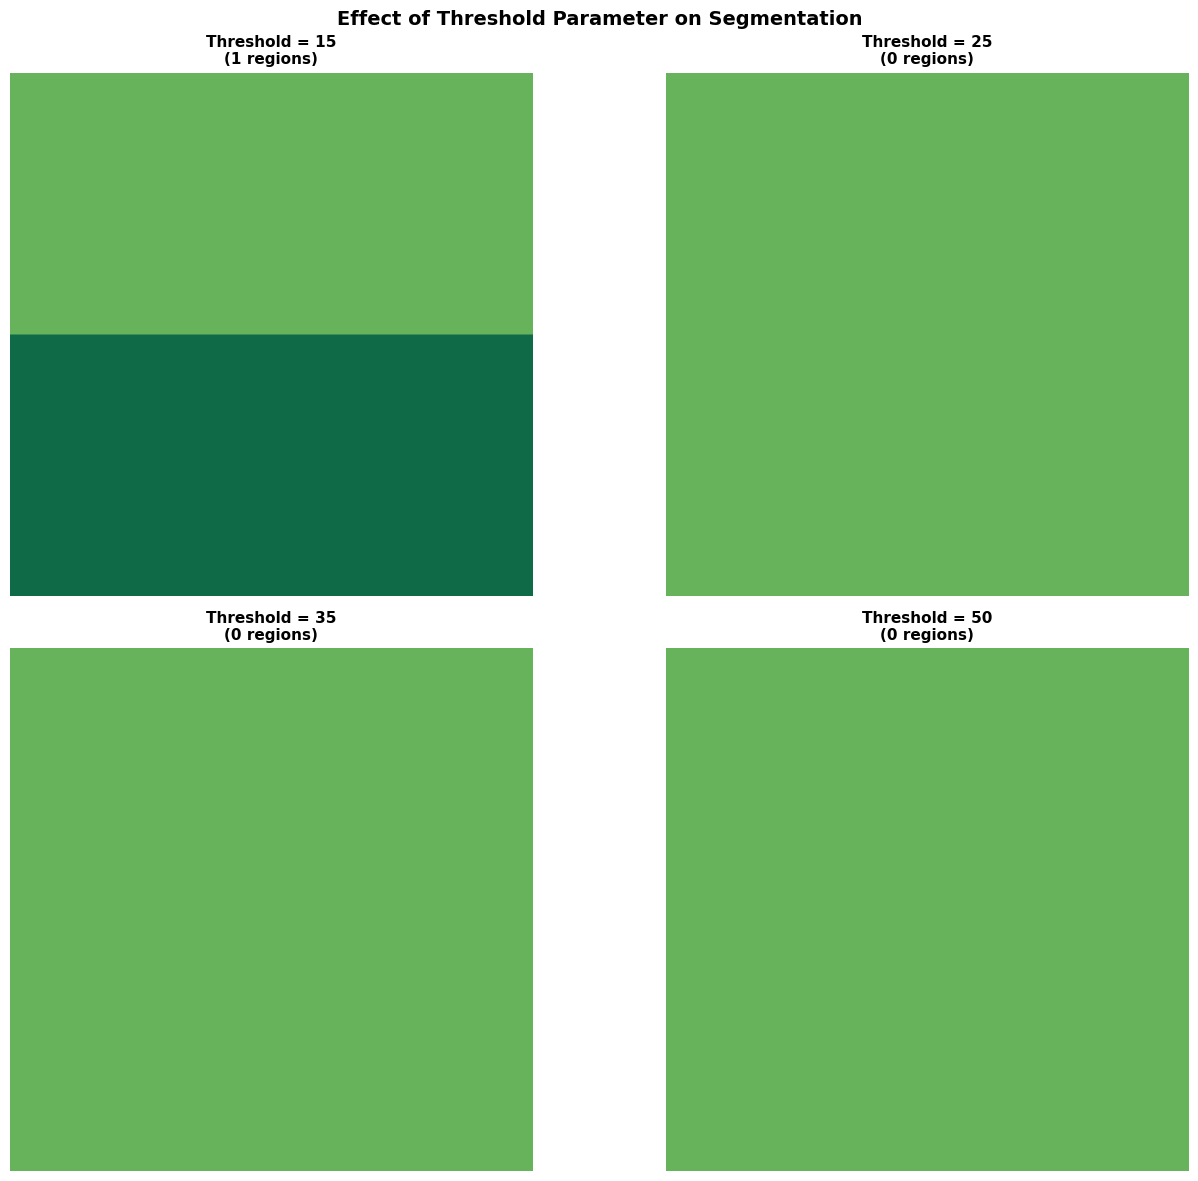

Observation: Lower thresholds create more regions (over-segmentation),
while higher thresholds create fewer regions (under-segmentation).


In [14]:
# Test with different threshold values
thresholds = [15, 25, 35, 50]
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for idx, threshold in enumerate(thresholds):
    ax = axes[idx // 2, idx % 2]
    
    # Create new segmenter with different threshold
    segmenter_test = RegionSplitMerge(image_gray, threshold=threshold, min_region_size=8)
    regions_test = segmenter_test.segment()
    colored_test = colorize_segmentation(regions_test)
    
    ax.imshow(colored_test)
    ax.set_title(f'Threshold = {threshold}\n({len(np.unique(regions_test))-1} regions)', 
                 fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle('Effect of Threshold Parameter on Segmentation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Observation: Lower thresholds create more regions (over-segmentation),")
print("while higher thresholds create fewer regions (under-segmentation).")


## Step 8: Application to Real-World Image (Optional)

If you have a real image, you can test the algorithm on it. Here's how to load and process a custom image:


In [ ]:
# Example: How to process a custom image
# Uncomment and modify the path to use your own image

"""
# Load custom image
custom_image_path = 'path_to_your_image.jpg'
custom_image = cv2.imread(custom_image_path)
custom_image = cv2.cvtColor(custom_image, cv2.COLOR_BGR2RGB)

# Resize if too large (for faster processing)
if custom_image.shape[0] > 800 or custom_image.shape[1] > 800:
    scale = 800 / max(custom_image.shape[:2])
    new_size = (int(custom_image.shape[1] * scale), int(custom_image.shape[0] * scale))
    custom_image = cv2.resize(custom_image, new_size)

custom_gray = cv2.cvtColor(custom_image, cv2.COLOR_RGB2GRAY)

# Apply segmentation
custom_segmenter = RegionSplitMerge(custom_gray, threshold=30, min_region_size=10)
custom_regions = custom_segmenter.segment()
custom_colored = colorize_segmentation(custom_regions)

# Apply SLIC
custom_slic = slic(custom_image, n_segments=150, compactness=10, sigma=1)
custom_slic_colored = label2rgb(custom_slic, custom_image, kind='avg')

# Display
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(custom_image)
plt.title('Original Custom Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(custom_colored)
plt.title('Region Split & Merge')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(custom_slic_colored)
plt.title('SLIC Segmentation')
plt.axis('off')
plt.show()
"""

print("Code template provided above for processing custom images.")
print("Uncomment and modify the path to use your own image.")


## Summary and Conclusions

### Key Findings:

1. **Region Splitting and Merging** provides better segmentation for complex images with multiple objects compared to simple thresholding methods.

2. **Thresholding methods** are faster and simpler but struggle with:
   - Images with varying illumination
   - Complex scenes with multiple objects
   - Images with similar intensity values for different objects

3. **SLIC segmentation** (similar to region splitting/merging) offers a good balance between:
   - Segmentation quality
   - Computational efficiency
   - Ease of use

### When to Use Each Method:

- **Use Thresholding** when:
  - Images have high contrast
  - Speed is critical
  - Simple binary segmentation is sufficient
  - Objects have distinct intensity values

- **Use Region Splitting & Merging** when:
  - Images have complex scenes
  - Multiple objects need to be segmented
  - Adaptive segmentation is required
  - Quality is more important than speed

- **Use SLIC** when:
  - You need a balance of quality and speed
  - Working with color images
  - Need superpixel-level segmentation
  - Want a well-tested, robust solution

### Recommendations:

For most practical applications, **SLIC segmentation** is recommended as it provides good results with reasonable computational cost. However, for educational purposes and understanding the fundamentals, implementing **Region Splitting and Merging** from scratch provides valuable insights into the segmentation process.
